In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [4]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.duplicated().sum()

1081

In [9]:
df.drop_duplicates(inplace=True)

# Exploratory Data Analysis (EDA)



In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

#Transaction Class Distribution (Fraud vs Genuine)

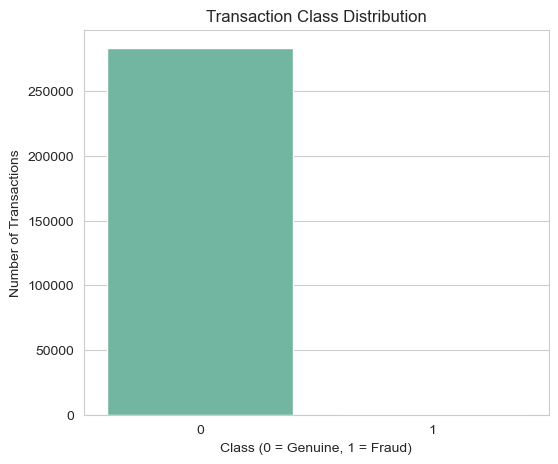

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Class',
    hue='Class',
    data=df,
    palette='Set2',
    legend=False
)

plt.title("Transaction Class Distribution")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.savefig("image/fraud vs genuine.png", dpi=300, bbox_inches="tight")
plt.show()

#Transaction Amount Distribution (Histogram)

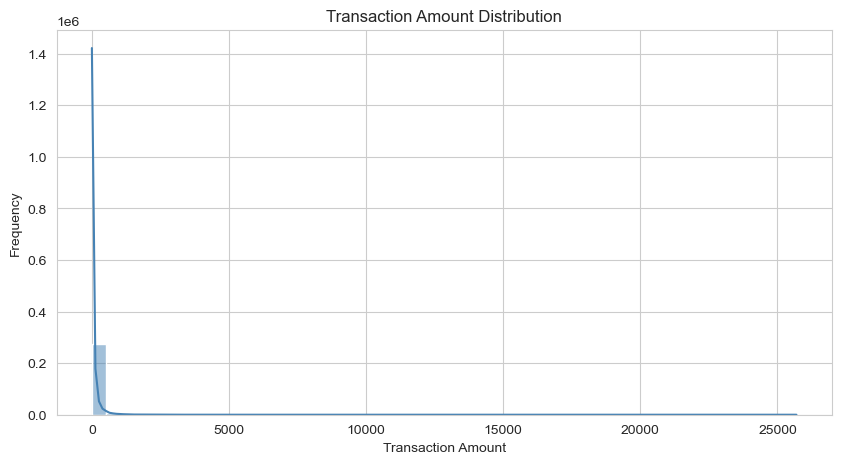

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50, kde=True, color='steelblue')

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.savefig("image/amount distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#Fraud Amount Distribution (Fraud vs Genuine)


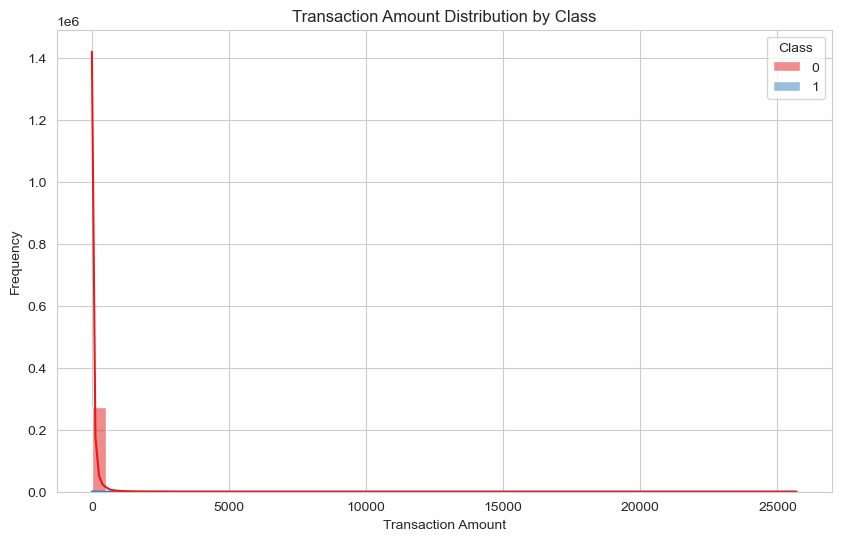

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    kde=True,
    palette="Set1"
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.savefig("image/fraud amount distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#Correlation Heatmap


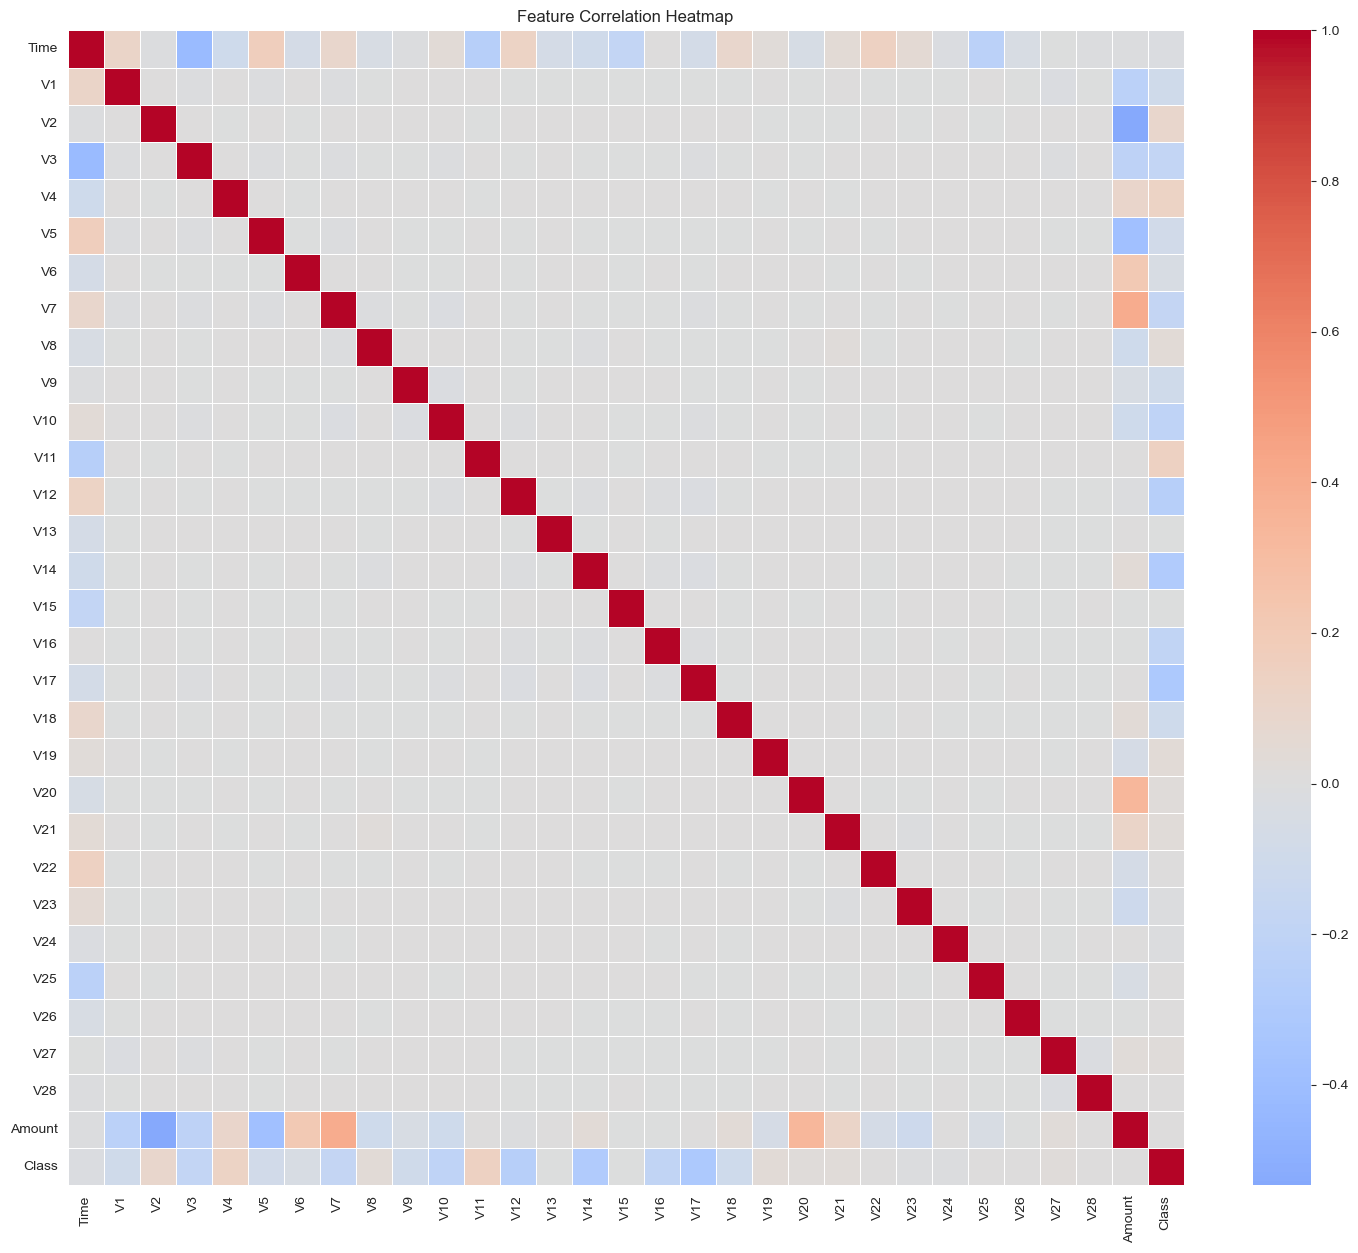

In [14]:
plt.figure(figsize=(18,15))

corr = df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.savefig("image/correlation heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

#Transaction Time Distribution


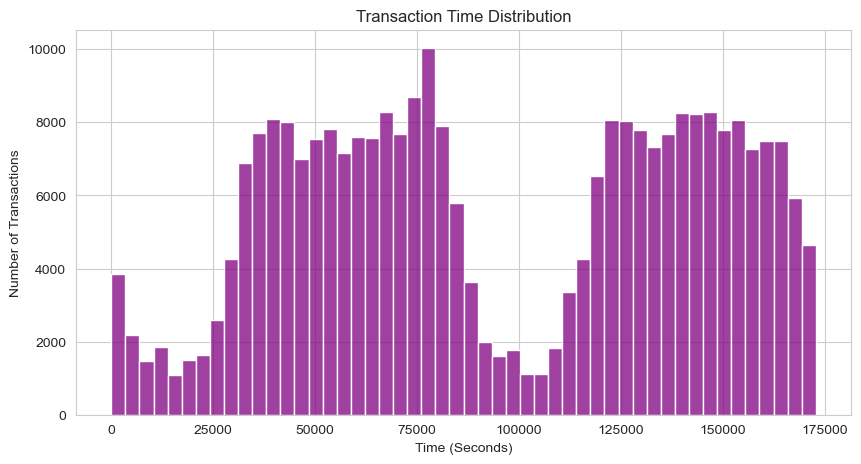

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(df['Time'], bins=50, color='purple')

plt.title("Transaction Time Distribution")
plt.xlabel("Time (Seconds)")
plt.ylabel("Number of Transactions")
plt.savefig("image/transaction time distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#Boxplot (Amount vs Class)


C:\Users\Anmol\AppData\Local\Temp\ipykernel_13608\3110483388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


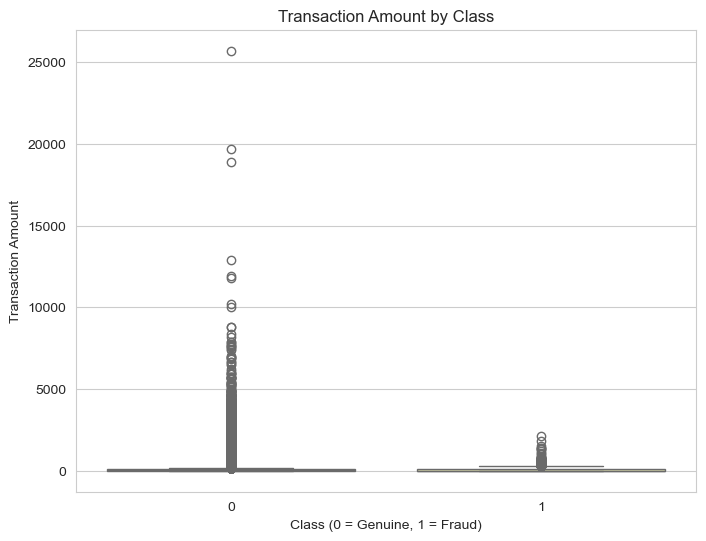

In [16]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Class',
    y='Amount',
    data=df,
    palette='Set3'
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.savefig("image/boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [18]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [19]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [20]:
class_percent = (df['Class'].value_counts(normalize=True) * 100)

print(class_percent)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


# Check fraud percentage

In [21]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [22]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [23]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.002,
    random_state=42
)

model.fit(X)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.002
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [24]:
pred = model.predict(X)

# Convert predictions
pred = [1 if x == -1 else 0 for x in pred]

In [25]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y, pred))
print(classification_report(y, pred))

[[282781    472]
 [   377     96]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    283253
           1       0.17      0.20      0.18       473

    accuracy                           1.00    283726
   macro avg       0.58      0.60      0.59    283726
weighted avg       1.00      1.00      1.00    283726



In [26]:
df["Predicted_Class"] = pred

In [27]:
df.to_csv("Fraud_Detection_Result.csv", index=False)

# Business Conclusion

This project demonstrates how anomaly detection techniques can be used to identify potentially fraudulent financial transactions. After performing data cleaning and exploratory data analysis, the dataset was analyzed using the Isolation Forest algorithm to detect unusual transaction patterns without relying on extensive labeled fraud data.

The exploratory analysis revealed that fraudulent transactions represent only a very small percentage of the total transactions, making fraud detection a challenging problem. The transaction amount and time analysis also showed that suspicious transactions often exhibit behavior different from normal transactions.

The Isolation Forest model successfully identified anomalous transactions by isolating observations that differ significantly from the majority of the data. The model's predictions were evaluated using a confusion matrix and classification report to measure its effectiveness in detecting potential fraud.

The predicted results were exported and used to build an interactive Power BI dashboard, enabling users to monitor fraud trends, view suspicious transactions, analyze transaction amounts, and support data-driven decision-making.

## Business Value

* Helps financial institutions identify potentially fraudulent transactions quickly.
* Reduces financial losses by enabling early detection of suspicious activities.
* Supports fraud investigation teams by prioritizing high-risk transactions.
* Provides interactive dashboards for real-time monitoring and business reporting.
* Demonstrates how machine learning and business intelligence can work together to improve fraud detection and operational efficiency.

## Future Enhancements

* Compare Isolation Forest with supervised models such as Random Forest and XGBoost.
* Develop a real-time fraud detection system using streaming transaction data.
* Deploy the trained model as a web application or REST API.
* Incorporate additional customer and transaction features to improve detection accuracy.
* Retrain the model periodically to adapt to new fraud patterns and evolving transaction behavior.

Overall, this project provides a practical end-to-end solution for detecting suspicious financial transactions by combining Python-based data analysis, machine learning, and Power BI visualization. It demonstrates valuable skills in data preprocessing, exploratory data analysis, anomaly detection, model evaluation, and business intelligence reporting.
